In [1]:
print("hello world, this is project is going to analyze my practice videos") 

hello world, this is project is going to analyze my practice videos


# architecture 

MP4
 ↓
librosa metrics
 ↓
frame extraction
 ↓
vision-language captions
 ↓
LLM summary
 ↓
practice report

In [21]:
import os 

import librosa 
from IPython.display import Audio
import subprocess 

from IPython.display import Audio 
import numpy as np

In [4]:
os.getcwd() 

'/home/joel/Documents/music_lesson_app/backend-fastapi/practice-video-extraction-logic'

extracting the audio from video 

In [3]:
# let's extract the audio from each video 
video_path = "/home/joel/Documents/music_lesson_app/backend-fastapi/video/waltz_no2_practice.mp4" 
audio_path = "output_audio_open_chord.wav"

subprocess.run([
    "ffmpeg", 
    "-i", video_path,
    "-vn",
    "-acodec", 
    "pcm_s16le",
    "-ar", 
    "16000", 
    "-ac", 
    "1", 
    audio_path

], check = True )






ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

CompletedProcess(args=['ffmpeg', '-i', '/home/joel/Documents/music_lesson_app/backend-fastapi/video/waltz_no2_practice.mp4', '-vn', '-acodec', 'pcm_s16le', '-ar', '16000', '-ac', '1', 'output_audio_open_chord.wav'], returncode=0)

In [2]:
wave_file = "/home/joel/Documents/music_lesson_app/backend-fastapi/practice-video-extraction-logic/output_audio_open_chord.wav"

music_array, sample_rate = librosa.load(wave_file )

# information I should find 

Rhythm consistency \
Dynamics (loud/soft) \
Stability of tone \
Pauses and hesitations \
Progress over time


In [4]:
tempo ,beat_frame = librosa.beat.beat_track(y = music_array, sr = sample_rate)

In [7]:
print(tempo,"bpm")

[64.59960938] bpm


# Getting frequency 

Rhythm consistency
Dynamics (loud/soft)
Stability of tone
Pauses and hesitations
Progress over time

In [ ]:
# tempo and beat 

tempo, beats = librosa.beat.beat_track(y=music_array, sr=sample_rate) 

# this gets average beats per minute 
# BPM vairance 
avg_tempo = round(tempo[0], 2)
print(avg_tempo, beats) 

64.6 [105 146]


In [18]:
beat_times = librosa.frames_to_time(beats, sr=sample_rate)
print(beat_times)

[2.43809524 3.39011338]


In [3]:
Audio(music_array, rate=sample_rate) 

In [22]:
beat_intervals = np.diff(beat_times)

instant_bpms = 60 / beat_intervals

In [23]:
avg_bpm = round(float(np.mean(instant_bpms)), 2)
bpm_variance = round(float(np.var(instant_bpms)), 2)
bpm_std = round(float(np.std(instant_bpms)), 2)

print("Average BPM:", avg_bpm)
print("BPM variance:", bpm_variance)
print("BPM standard deviation:", bpm_std)
print("Instant BPMs:", instant_bpms)

Average BPM: 63.02
BPM variance: 0.0
BPM standard deviation: 0.0
Instant BPMs: [63.02400915]


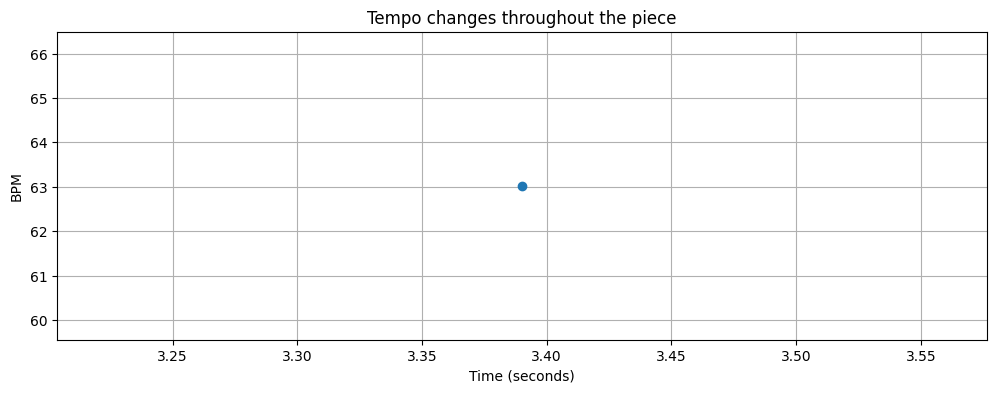

In [25]:
import matplotlib.pyplot as plt

bpm_times = beat_times[1:]

plt.figure(figsize=(12, 4))
plt.plot(bpm_times, instant_bpms, marker="o")
plt.xlabel("Time (seconds)")
plt.ylabel("BPM")
plt.title("Tempo changes throughout the piece")
plt.grid(True)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (0,) and (4,)

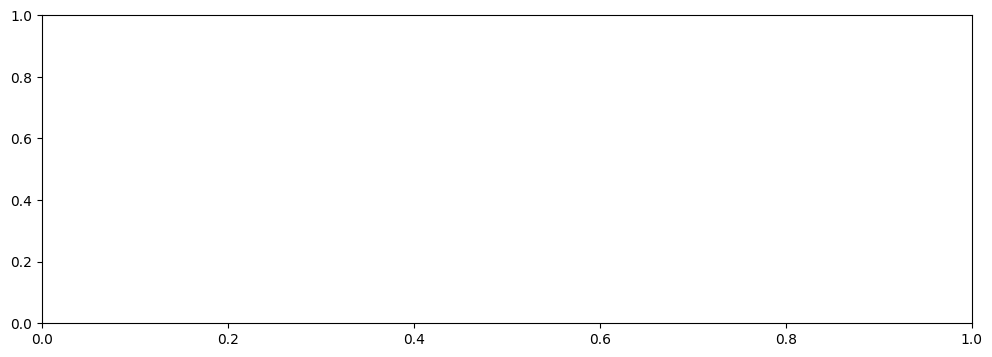

In [28]:
window = 4

smoothed_bpms = np.convolve(
    instant_bpms,
    np.ones(window) / window,
    mode="valid"
)

smoothed_times = bpm_times[window - 1:]

plt.figure(figsize=(12, 4))
plt.plot(smoothed_times, smoothed_bpms)
plt.xlabel("Time (seconds)")
plt.ylabel("BPM")
plt.title("Smoothed tempo changes")
plt.grid(True)
plt.show()

In [43]:
# pause detection 

intervals = librosa.effects.split(
    music_array,
    top_db=20
)

intervals

array([[    0, 15872],
       [19456, 92672]])

In [47]:
interval_times = librosa.samples_to_time(intervals, sr=sample_rate)
print(interval_times)

print(f"non silence on parts {interval_times} seconds")

[[0.         0.71981859]
 [0.88235828 4.20281179]]
non silence on parts [[0.         0.71981859]
 [0.88235828 4.20281179]] seconds


In [49]:
import librosa
import numpy as np

intervals = librosa.effects.split(music_array, top_db=20)
interval_times = librosa.samples_to_time(intervals, sr=sample_rate)

pauses = []

for i in range(len(interval_times) - 1):
    pause_duration = interval_times[i + 1][0] - interval_times[i][1]

    if pause_duration >= 0.3:
        pauses.append(pause_duration)

pauses = np.array(pauses)

number_of_pauses = len(pauses)
longest_pause = pauses.max() if len(pauses) > 0 else 0
total_silence_time = pauses.sum() if len(pauses) > 0 else 0

print(f"{number_of_pauses} pauses detected")
print(f"Longest pause: {longest_pause:.2f} seconds")
print(f"Total silence time: {total_silence_time:.2f} seconds")

0 pauses detected
Longest pause: 0.00 seconds
Total silence time: 0.00 seconds


In [51]:
# volume variation dynamic range 

rms = librosa.feature.rms(y= music_array)[0]

# Metrics:

# Average volume
# Max volume
# Min volume
# Dynamic range

# Example:

# Dynamic range: 18 dB
# Consistent volume throughout performance


rms

array([0.10099847, 0.12398042, 0.14304206, 0.1430809 , 0.14567892,
       0.14487608, 0.14675798, 0.14354727, 0.14353646, 0.14166111,
       0.14086741, 0.14093952, 0.14209652, 0.14291458, 0.14424056,
       0.14551422, 0.14867193, 0.1534603 , 0.1571402 , 0.15722346,
       0.14611462, 0.1366373 , 0.11809997, 0.10217873, 0.08811291,
       0.07020735, 0.05428825, 0.04155438, 0.03349456, 0.02494783,
       0.02134108, 0.01782246, 0.01598472, 0.01635851, 0.01703542,
       0.01790099, 0.01830805, 0.01910467, 0.01973932, 0.02033812,
       0.02216482, 0.02316602, 0.02470352, 0.02621651, 0.02823518,
       0.03040762, 0.03267614, 0.03419202, 0.03746861, 0.04044319,
       0.0437967 , 0.04695132, 0.0493318 , 0.05103427, 0.05265388,
       0.05560396, 0.05711263, 0.05825331, 0.0576432 , 0.05734221,
       0.05710777, 0.05883508, 0.06006797, 0.06242738, 0.06386574,
       0.0665812 , 0.06999931, 0.07301655, 0.07534264, 0.0749406 ,
       0.07495859, 0.07288892, 0.07144902, 0.07053342, 0.06921

In [53]:
intervals = librosa.effects.split(music_array, top_db=40)

non_silent_audio = np.concatenate([
    music_array[start:end] for start, end in intervals
])

rms = librosa.feature.rms(y=non_silent_audio)[0]
rms_db = librosa.amplitude_to_db(rms, ref=np.max)

avg_volume_db = np.mean(rms_db)
max_volume_db = np.max(rms_db)
min_volume_db = np.min(rms_db)
dynamic_range_db = max_volume_db - min_volume_db

print(f"Average volume: {avg_volume_db:.2f} dB")
print(f"Max volume: {max_volume_db:.2f} dB")
print(f"Min volume: {min_volume_db:.2f} dB")
print(f"Dynamic range: {dynamic_range_db:.2f} dB")


Average volume: -11.28 dB
Max volume: 0.00 dB
Min volume: -33.65 dB
Dynamic range: 33.65 dB


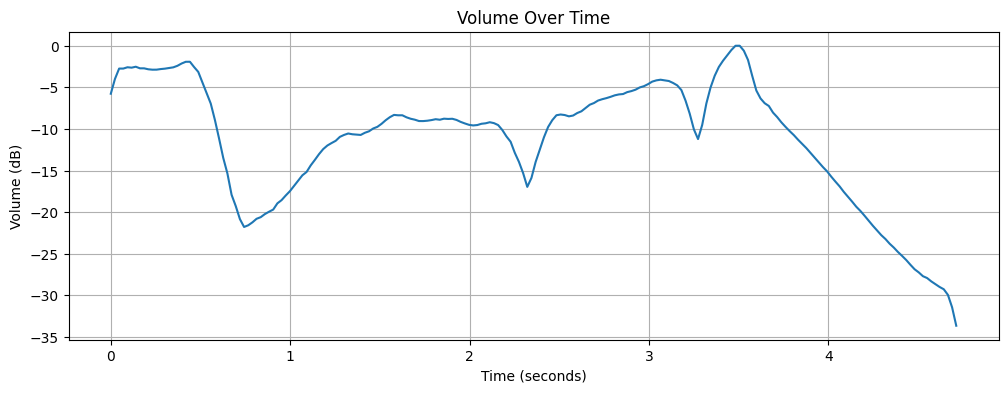

In [54]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

rms = librosa.feature.rms(y=music_array)[0]
rms_db = librosa.amplitude_to_db(rms, ref=np.max)

times = librosa.frames_to_time(
    np.arange(len(rms_db)),
    sr=sample_rate
)

plt.figure(figsize=(12, 4))
plt.plot(times, rms_db)
plt.xlabel("Time (seconds)")
plt.ylabel("Volume (dB)")
plt.title("Volume Over Time")
plt.grid(True)
plt.show()

In [55]:
section_size = len(rms_db) // 4

start_volume = np.mean(rms_db[:section_size])
end_volume = np.mean(rms_db[-section_size:])

volume_change = end_volume - start_volume

print(f"Start volume: {start_volume:.2f} dB")
print(f"End volume: {end_volume:.2f} dB")
print(f"Volume change: {volume_change:.2f} dB")

if volume_change > 3:
    print("Volume increased gradually through the performance.")
elif volume_change < -3:
    print("Volume faded through the performance.")
else:
    print("Volume stayed mostly consistent.")

Start volume: -10.39 dB
End volume: -18.38 dB
Volume change: -7.99 dB
Volume faded through the performance.


In [56]:
window_size = 10

smoothed_rms = np.convolve(
    rms_db,
    np.ones(window_size) / window_size,
    mode="valid"
)

smoothed_times = times[window_size - 1:]

crescendos = []

for i in range(len(smoothed_rms) - window_size):
    start = smoothed_rms[i]
    end = smoothed_rms[i + window_size]

    if end - start > 4:
        crescendos.append((smoothed_times[i], smoothed_times[i + window_size], end - start))

print(f"{len(crescendos)} possible crescendos detected")

for start_time, end_time, change in crescendos:
    print(f"Crescendo from {start_time:.2f}s to {end_time:.2f}s: +{change:.2f} dB")

25 possible crescendos detected
Crescendo from 0.91s to 1.14s: +4.11 dB
Crescendo from 0.93s to 1.16s: +4.67 dB
Crescendo from 0.95s to 1.18s: +5.05 dB
Crescendo from 0.98s to 1.21s: +5.28 dB
Crescendo from 1.00s to 1.23s: +5.45 dB
Crescendo from 1.02s to 1.25s: +5.55 dB
Crescendo from 1.04s to 1.28s: +5.61 dB
Crescendo from 1.07s to 1.30s: +5.59 dB
Crescendo from 1.09s to 1.32s: +5.55 dB
Crescendo from 1.11s to 1.35s: +5.37 dB
Crescendo from 1.14s to 1.37s: +5.08 dB
Crescendo from 1.16s to 1.39s: +4.71 dB
Crescendo from 1.18s to 1.42s: +4.30 dB
Crescendo from 2.39s to 2.62s: +4.65 dB
Crescendo from 2.41s to 2.65s: +5.09 dB
Crescendo from 2.44s to 2.67s: +5.24 dB
Crescendo from 2.46s to 2.69s: +5.19 dB
Crescendo from 2.48s to 2.72s: +4.92 dB
Crescendo from 2.51s to 2.74s: +4.53 dB
Crescendo from 2.53s to 2.76s: +4.04 dB
Crescendo from 3.30s to 3.53s: +4.63 dB
Crescendo from 3.32s to 3.55s: +5.43 dB
Crescendo from 3.34s to 3.58s: +5.65 dB
Crescendo from 3.37s to 3.60s: +5.39 dB
Crescend

In [57]:
if volume_change > 3:
    feedback = "Volume increased gradually through final section."
elif volume_change < -3:
    feedback = "Volume faded toward the end."
elif len(crescendos) > 0:
    feedback = "Crescendos were present."
else:
    feedback = "Volume stayed mostly consistent."

print(feedback)

Volume faded toward the end.


Average pitch: 119.99 Hz
Average pitch note: B2
Pitch variance: 6135.10
Pitch standard deviation: 78.33 Hz
Pitch variance: 834878.73 cents
Pitch stability: 913.72 cents
1 pitch jumps detected
Pitch jump around 0:03
1 large pitch jumps detected
Estimated vibrato frequency: 1.96 Hz


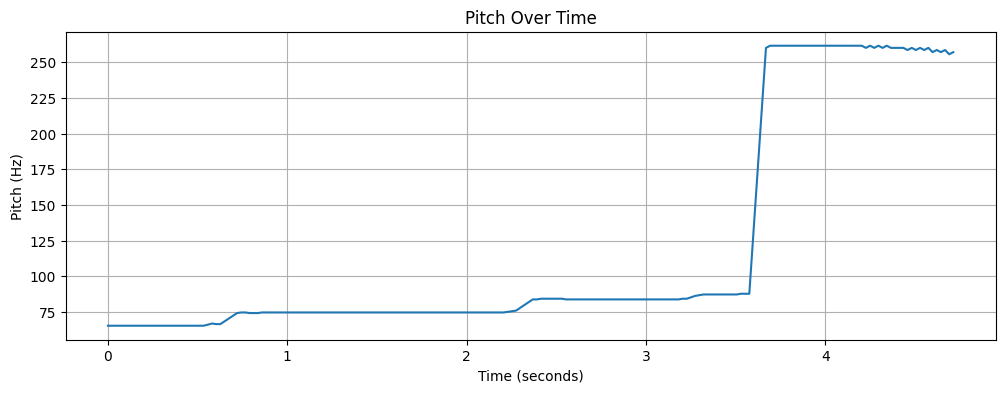

Several large pitch deviations detected.


In [ ]:
# pitch variance, good for one single-note audio

f0, voiced_flag, voiced_probs = librosa.pyin(
    music_array,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C7"),
    sr=sample_rate
)
times = librosa.times_like(f0, sr=sample_rate)

voiced_f0 = f0[~np.isnan(f0)]
voiced_times = times[~np.isnan(f0)]



average_pitch_hz = np.mean(voiced_f0)
average_pitch_note = librosa.hz_to_note(average_pitch_hz)

print(f"Average pitch: {average_pitch_hz:.2f} Hz")
print(f"Average pitch note: {average_pitch_note}")


pitch_variance = np.var(voiced_f0)
pitch_std = np.std(voiced_f0)

print(f"Pitch variance: {pitch_variance:.2f}")
print(f"Pitch standard deviation: {pitch_std:.2f} Hz")


pitch_cents = 1200 * np.log2(voiced_f0 / np.mean(voiced_f0))

pitch_variance_cents = np.var(pitch_cents)
pitch_std_cents = np.std(pitch_cents)

print(f"Pitch variance: {pitch_variance_cents:.2f} cents")
print(f"Pitch stability: {pitch_std_cents:.2f} cents")


pitch_diff = np.abs(np.diff(voiced_f0))
time_diff = voiced_times[1:]

jump_threshold_hz = 80

pitch_jumps = time_diff[pitch_diff > jump_threshold_hz]

print(f"{len(pitch_jumps)} pitch jumps detected")

for t in pitch_jumps:
    minutes = int(t // 60)
    seconds = int(t % 60)
    print(f"Pitch jump around {minutes}:{seconds:02d}")



pitch_cents_series = 1200 * np.log2(voiced_f0 / voiced_f0[0])
pitch_jumps_cents = np.abs(np.diff(pitch_cents_series))

jump_threshold_cents = 200  # about 2 semitones

jump_times = voiced_times[1:][pitch_jumps_cents > jump_threshold_cents]

print(f"{len(jump_times)} large pitch jumps detected")





from scipy.signal import find_peaks

pitch_cents = 1200 * np.log2(voiced_f0 / np.mean(voiced_f0))

peaks, _ = find_peaks(pitch_cents, distance=3)

if len(peaks) > 1:
    peak_times = voiced_times[peaks]
    vibrato_periods = np.diff(peak_times)
    vibrato_frequency = 1 / np.mean(vibrato_periods)

    print(f"Estimated vibrato frequency: {vibrato_frequency:.2f} Hz")
else:
    vibrato_frequency = 0
    print("No clear vibrato detected")



plt.figure(figsize=(12, 4))
plt.plot(voiced_times, voiced_f0)
plt.xlabel("Time (seconds)")
plt.ylabel("Pitch (Hz)")
plt.title("Pitch Over Time")
plt.grid(True)
plt.show()



if pitch_std_cents < 25:
    print("Sustained notes showed stable pitch.")
elif pitch_std_cents < 60:
    print("Some pitch variation detected.")
else:
    print("Several large pitch deviations detected.")

In [ ]:
# centroids 

# For cello, don’t treat the thresholds as universal. A high note played softly can still have a higher centroid than a low note played aggressively. This works best as a rough tone-brightness metric, especially when comparing sections of the same performance.

import librosa
import numpy as np
import matplotlib.pyplot as plt

centroid = librosa.feature.spectral_centroid(
    y=music_array,
    sr=sample_rate
)[0]

centroid_times = librosa.frames_to_time(
    np.arange(len(centroid)),
    sr=sample_rate
)

avg_centroid = np.mean(centroid)
centroid_std = np.std(centroid)

print(f"Average spectral centroid: {avg_centroid:.2f} Hz")
print(f"Centroid variation: {centroid_std:.2f} Hz")


if avg_centroid < 1000:
    tone_feedback = "Tone remained consistently warm."
elif avg_centroid < 1800:
    tone_feedback = "Tone had a balanced warmth and brightness."
else:
    tone_feedback = "Tone was bright or aggressive."
    
print(tone_feedback)


section_size = len(centroid) // 4

start_centroid = np.mean(centroid[:section_size])
end_centroid = np.mean(centroid[-section_size:])

centroid_change = end_centroid - start_centroid

if centroid_change > 300:
    print("Tone became brighter toward the end.")
elif centroid_change < -300:
    print("Tone became warmer toward the end.")
else:
    print("Tone color stayed mostly consistent.")



rms = librosa.feature.rms(y=music_array)[0]
rms_db = librosa.amplitude_to_db(rms, ref=np.max)

non_silent_frames = rms_db > -40

centroid_playing = centroid[non_silent_frames]

avg_centroid = np.mean(centroid_playing)
centroid_std = np.std(centroid_playing)

print(f"Average playing centroid: {avg_centroid:.2f} Hz")
print(f"Tone variation: {centroid_std:.2f} Hz")

Average spectral centroid: 541.88 Hz
Centroid variation: 139.35 Hz
Tone remained consistently warm.
Tone color stayed mostly consistent.
Average playing centroid: 541.88 Hz
Tone variation: 139.35 Hz


In [ ]:
# spectral bandwidth
# 
# scratchy bowing 

import librosa
import numpy as npavg_rms = np.mean(rms[playing_frames])
rms_stability = np.std(rms[playing_frames])
avg_flatness = np.mean(flatness_playing)

if avg_rms > 0.03 and avg_flatness < 0.015:
    resonance_feedback = "Rich resonance detected."
else:
    resonance_feedback = "Resonance could be stronger."
    
print(resonance_feedback)

centroid = librosa.feature.spectral_centroid(y=music_array, sr=sample_rate)[0]
flatness = librosa.feature.spectral_flatness(y=music_array)[0]
rms = librosa.feature.rms(y=music_array)[0]

rms_db = librosa.amplitude_to_db(rms, ref=np.max)
playing_frames = rms_db > -40

centroid_playing = centroid[playing_frames]
flatness_playing = flatness[playing_frames]

avg_centroid = np.mean(centroid_playing)
avg_flatness = np.mean(flatness_playing)

if avg_centroid > 1800 and avg_flatness > 0.02:
    scratch_feedback = "Scratchy bowing detected."
else:
    scratch_feedback = "Bowing tone sounded mostly clean."

print(scratch_feedback)

Bowing tone sounded mostly clean.


In [72]:
# rich resonance 

avg_rms = np.mean(rms[playing_frames])
rms_stability = np.std(rms[playing_frames])
avg_flatness = np.mean(flatness_playing)

if avg_rms > 0.03 and avg_flatness < 0.015:
    resonance_feedback = "Rich resonance detected."
else:
    resonance_feedback = "Resonance could be stronger."
    
print(resonance_feedback)

Rich resonance detected.


In [73]:
# tone consistency

centroid_std = np.std(centroid_playing)

if centroid_std < 300:
    consistency_feedback = "Tone remained consistent."
elif centroid_std < 600:
    consistency_feedback = "Tone had some variation."
else:
    consistency_feedback = "Tone consistency varied noticeably."

print(consistency_feedback)

Tone remained consistent.


In [74]:
print("Average centroid:", round(avg_centroid, 2), "Hz")
print("Average flatness:", round(avg_flatness, 4))
print("Centroid variation:", round(centroid_std, 2), "Hz")

print(scratch_feedback)
print(resonance_feedback)
print(consistency_feedback)

Average centroid: 541.88 Hz
Average flatness: 0.0
Centroid variation: 139.35 Hz
Bowing tone sounded mostly clean.
Rich resonance detected.
Tone remained consistent.


In [75]:
# may 

import librosa
import numpy as np
import matplotlib.pyplot as plt

onset_frames = librosa.onset.onset_detect(
    y=music_array,
    sr=sample_rate,
    units="frames"
)

onset_times = librosa.frames_to_time(onset_frames, sr=sample_rate)

duration_seconds = librosa.get_duration(y=music_array, sr=sample_rate)
duration_minutes = duration_seconds / 60

notes_per_minute = len(onset_times) / duration_minutes

print(f"Detected attacks: {len(onset_times)}")
print(f"Notes per minute: {notes_per_minute:.2f}")

Detected attacks: 21
Notes per minute: 267.25


In [76]:
window_seconds = 10

bins = np.arange(0, duration_seconds + window_seconds, window_seconds)
attack_counts, _ = np.histogram(onset_times, bins=bins)

attack_density = attack_counts / window_seconds

for i, density in enumerate(attack_density):
    start = bins[i]
    end = bins[i + 1]
    print(f"{start:.0f}s-{end:.0f}s: {density:.2f} attacks/sec")

0s-10s: 2.10 attacks/sec


In [77]:
attack_intervals = np.diff(onset_times)

avg_attack_interval = np.mean(attack_intervals)
attack_interval_std = np.std(attack_intervals)

print(f"Average attack spacing: {avg_attack_interval:.2f} seconds")
print(f"Attack irregularity: {attack_interval_std:.2f} seconds")

Average attack spacing: 0.23 seconds
Attack irregularity: 0.15 seconds


In [78]:
if attack_interval_std < 0.1:
    attack_feedback = "Attacks were rhythmically consistent."
elif attack_interval_std < 0.25:
    attack_feedback = "Some irregular attacks detected."
else:
    attack_feedback = "Irregular attacks detected."

print(attack_feedback)

Some irregular attacks detected.


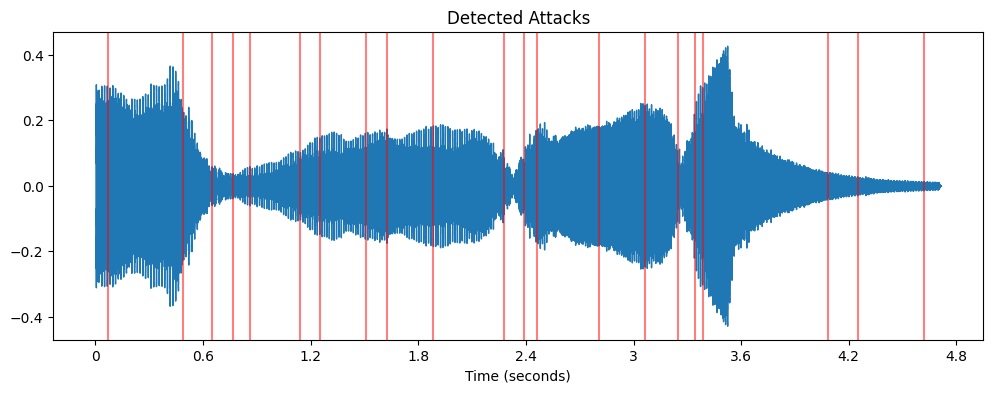

In [ ]:
# summary of detected attacks 
import librosa.display

plt.figure(figsize=(12, 4))
librosa.display.waveshow(music_array, sr=sample_rate)

for t in onset_times:
    plt.axvline(t, color="red", alpha=0.5)

plt.xlabel("Time (seconds)")
plt.title("Detected Attacks")
plt.show()

In [81]:
session_length_seconds = librosa.get_duration(
    y=music_array,
    sr=sample_rate
)

minutes = int(session_length_seconds // 60)
seconds = int(session_length_seconds % 60)

print(f"Session length: {minutes} min {seconds} sec")

Session length: 0 min 4 sec


In [86]:
import librosa
import numpy as np

def format_time(seconds):
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}:{secs:02d}"

rms = librosa.feature.rms(y=music_array)[0]
rms_db = librosa.amplitude_to_db(rms, ref=np.max)

rms_times = librosa.frames_to_time(
    np.arange(len(rms_db)),
    sr=sample_rate
)


intervals = librosa.effects.split(
    music_array,
    top_db=40
)

interval_times = librosa.samples_to_time(intervals, sr=sample_rate)

pauses = []

for i in range(len(interval_times) - 1):
    pause_start = interval_times[i][1]
    pause_end = interval_times[i + 1][0]
    pause_duration = pause_end - pause_start

    if pause_duration >= 0.3:
        pauses.append({
            "start": pause_start,
            "end": pause_end,
            "duration": pause_duration
        })



session_length_seconds = librosa.get_duration(
    y=music_array,
    sr=sample_rate
)

window_seconds = 35

bins = np.arange(
    0,
    session_length_seconds + window_seconds,
    window_seconds
)

sections = []

for i in range(len(bins) - 1):
    start = bins[i]
    end = bins[i + 1]

    window_pauses = [
        pause for pause in pauses
        if start <= pause["start"] < end
    ]

    pause_count = len(window_pauses)
    total_pause_time = sum(pause["duration"] for pause in window_pauses)

    rms_in_window = rms_db[
        (rms_times >= start) & (rms_times < end)
    ]

    avg_rms = np.mean(rms_in_window) if len(rms_in_window) > 0 else -80
    rms_variance = np.var(rms_in_window) if len(rms_in_window) > 0 else 0

    difficulty_score = (
        pause_count * 2.0
        + total_pause_time * 1.5
        + rms_variance * 0.05
    )

    sections.append({
        "start": start,
        "end": min(end, session_length_seconds),
        "pause_count": pause_count,
        "total_pause_time": total_pause_time,
        "avg_rms_db": avg_rms,
        "rms_variance": rms_variance,
        "difficulty_score": difficulty_score
    })



hardest_section = max(
    sections,
    key=lambda section: section["difficulty_score"]
)

print(
    f"Most interruptions occurred between "
    f"{format_time(hardest_section['start'])}-"
    f"{format_time(hardest_section['end'])}."
)

print(f"Pauses: {hardest_section['pause_count']}")
print(f"Total pause time: {hardest_section['total_pause_time']:.2f}s")
print(f"Average volume: {hardest_section['avg_rms_db']:.2f} dB")
print(f"Volume variance: {hardest_section['rms_variance']:.2f}")
print(f"Difficulty score: {hardest_section['difficulty_score']:.2f}")


ranked_sections = sorted(
    sections,
    key=lambda section: section["difficulty_score"],
    reverse=True
)

for section in ranked_sections[:3]:
    print(
        f"{format_time(section['start'])}-"
        f"{format_time(section['end'])}: "
        f"score={section['difficulty_score']:.2f}, "
        f"pauses={section['pause_count']}, "
        f"pause_time={section['total_pause_time']:.2f}s"
    )


if hardest_section["pause_count"] == 0:
    feedback = "No major difficult section detected from pauses."
else:
    feedback = (
        f"Most interruptions occurred between "
        f"{format_time(hardest_section['start'])}-"
        f"{format_time(hardest_section['end'])}. "
        f"This section may need focused practice."
    )

print(feedback)

Most interruptions occurred between 0:00-0:04.
Pauses: 0
Total pause time: 0.00s
Average volume: -11.28 dB
Volume variance: 54.04
Difficulty score: 2.70
0:00-0:04: score=2.70, pauses=0, pause_time=0.00s
No major difficult section detected from pauses.
